In [1]:
# import functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import seaborn as sns

In [2]:
# import files
anthracis_f1 = pd.read_csv("bacillus_anthracis_f1_blast_plot-table.csv")
print(anthracis_f1.head(10))
botulinum_f1 = pd.read_csv("clostridium_botulinum_f1_blast_plot-table.csv")
coliO157_f1 = pd.read_csv("escherichia_colio157_f1_blast_plot-table.csv")
fttularensis_f1 = pd.read_csv("francisella_ttularensis_f1_blast_plot-table.csv")
pestis_f1 = pd.read_csv("yersinia_pestis_f1_blast_plot-table.csv")

   ratios     count         patho_decoy
0     1:0  283410.0  Simulated Pathogen
1  1000:1  283126.0  Simulated Pathogen
2   500:1  282844.0  Simulated Pathogen
3   100:1  280576.0  Simulated Pathogen
4    50:1  277742.0  Simulated Pathogen
5    10:1  255069.0  Simulated Pathogen
6     5:1  226728.0  Simulated Pathogen
7     1:1  141706.0  Simulated Pathogen
8     1:5   56682.0  Simulated Pathogen
9    1:10   28341.0  Simulated Pathogen


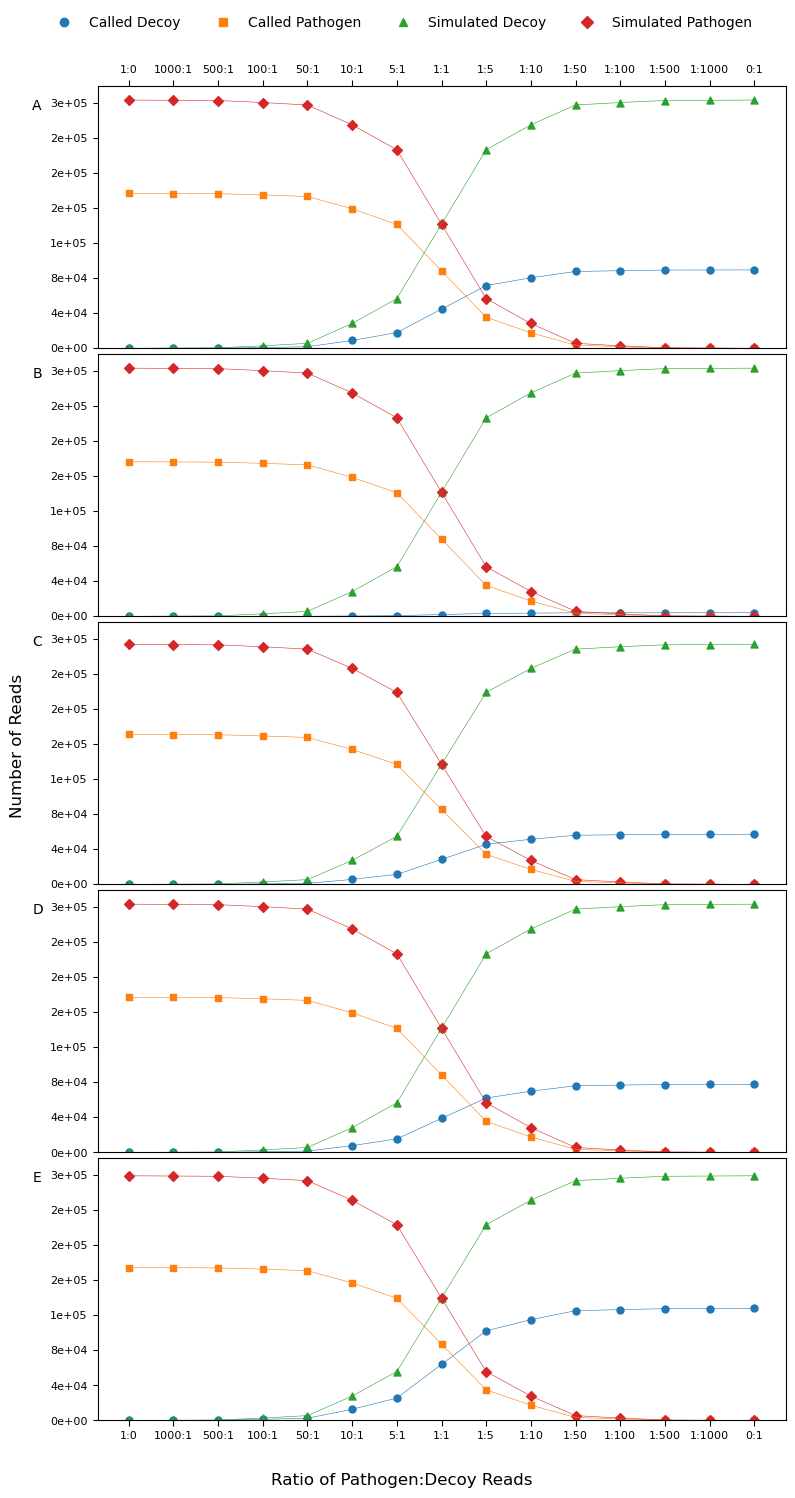

In [3]:
# ratio order
ratio_order = ["1:0", "1000:1", "500:1", "100:1", "50:1", "10:1", "5:1", "1:1", "1:5", "1:10", "1:50", "1:100", "1:500", "1:1000", "0:1"]

# categories
categories = [
    "Called Decoy",
    "Called Pathogen",
    "Simulated Decoy",
    "Simulated Pathogen"
]

# marker shapes
markers = {
    "Called Decoy": "o",
    "Called Pathogen": "s",
    "Simulated Decoy": "^",
    "Simulated Pathogen": "D"
}

# colours
colors = {
    "Simulated Pathogen": "tab:red",
    "Called Pathogen": "tab:orange",
    "Simulated Decoy": "tab:green",
    "Called Decoy": "tab:blue"
}

# create 5-panel
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(8, 15),
    sharex=True 
)

# function to draw each dataset on an axis
def plot_f1(ax, data):
    data = data.copy()
    data["ratios"] = pd.Categorical(
        data["ratios"],
        categories=ratio_order,
        ordered=True
    )
    for category in categories:
        df = data[
            data["patho_decoy"] == category
        ].sort_values("ratios")
        if df.empty:
            continue
        x = df["ratios"].cat.codes
        #remove any ratios that are not in ratio_order
        valid = x>=0
        x = x[valid]
        y = df.loc[valid, "count"]
        # add points
        ax.scatter(
            x, y,
            marker=markers[category],
            color=colors[category],
            alpha=1,
            s=25
        )
        # add line
        ax.plot(
            x, y,
            color=colors[category],
            linewidth=0.4
        )

# plot the five datasets
plot_f1(axes[0], anthracis_f1)
plot_f1(axes[1], botulinum_f1)
plot_f1(axes[2], coliO157_f1)
plot_f1(axes[3], fttularensis_f1)
plot_f1(axes[4], pestis_f1)

# panel labels
labels = ["A", "B", "C", "D", "E"]

for ax, label in zip(axes, labels):

    ax.text(
        -0.095,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=10,
        color="black",
        va="top",
        ha="left"
    )

# x-axis positions
x_position = np.arange(len(ratio_order))
for ax in axes:
    ax.set_xticks(x_position)

# plot A x-axis settings
axes[0].xaxis.tick_top()
axes[0].set_xticks(x_position)
axes[0].set_xticklabels(ratio_order)

axes[0].tick_params(
    axis="x",
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    length=4,
    labelsize=8
)

# plots B-D x-axis labels and ticks removal
for ax in axes[1:4]:

    ax.set_xticklabels([])
    ax.tick_params(
        axis="x",
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False
    )

# plot E - x-axis
axes[4].xaxis.tick_bottom()
axes[4].set_xticks(x_position)
axes[4].set_xticklabels(ratio_order)

axes[4].tick_params(
    axis="x",
    bottom=True,
    labelbottom=True,
    top=False,
    labeltop=False,
    length=4,
    labelsize=8
)

# y-axis settings
for ax in axes:
    ax.set_ylim(0, 300000)
    ax.set_yticks(
        np.arange(0, 300001, 40000)
    )
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:.0e}")
    )
    ax.tick_params(
        axis="y",
        labelsize=8
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

# legends

legend_elements = [
    Line2D(
        [0], [0],
        marker=markers[category],
        color=colors[category],
        markerfacecolor=colors[category],
        markeredgecolor=colors[category],
        linestyle="None",
        markersize=6,
        label=category
    )
    for category in categories
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    fontsize=10
)

# whole figure axis labels
fig.text(
    0.02,
    0.5,
    "Number of Reads",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12
)

fig.text(
    0.5,
    0.01,
    "Ratio of Pathogen:Decoy Reads",
    ha="center",
    va="center",
    fontsize=12
)

# layout
plt.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.94,
    bottom=0.05,
    hspace=0.02
)

# save image
fig.savefig("IMAGES/figure_PathogenandDecoy_F1.png",
            dpi=600, bbox_inches="tight", facecolor="white"
)

plt.show()

In [4]:
# import files
thuringiensis_f1 = pd.read_csv("bacillus_thuringiensis_f1_blast_plot-table.csv")
print(thuringiensis_f1.head(10))
sporogenes_f1 = pd.read_csv("clostridium_sporogenes_f1_blast_plot-table.csv")
coliSE11_f1 = pd.read_csv("escherichia_colise11_f1_blast_plot-table.csv")
ftnovicida_f1 = pd.read_csv("francisella_tnovicida_f1_blast_plot-table.csv")
pseudot_f1 = pd.read_csv("yersinia_pseudotuberculosis_f1_blast_plot-table.csv")

   ratios     count         patho_decoy
0     1:0  283410.0  Simulated Pathogen
1  1000:1  283126.0  Simulated Pathogen
2   500:1  282844.0  Simulated Pathogen
3   100:1  280576.0  Simulated Pathogen
4    50:1  277742.0  Simulated Pathogen
5    10:1  255069.0  Simulated Pathogen
6     5:1  226728.0  Simulated Pathogen
7     1:1  141706.0  Simulated Pathogen
8     1:5   56682.0  Simulated Pathogen
9    1:10   28341.0  Simulated Pathogen


In [5]:
# remove decoy data from all dataframes
rows = thuringiensis_f1[thuringiensis_f1["patho_decoy"].isin([ "Simulated Decoy", "Called Decoy"])].index
thuringiensis_f1_df = thuringiensis_f1.drop(rows)
print(thuringiensis_f1_df)
sporogenes_f1_df = sporogenes_f1.drop(rows)
coliSE11_f1_df = coliSE11_f1.drop(rows)
ftnovicida_f1_df = ftnovicida_f1.drop(rows)
pseudot_f1_df = pseudot_f1.drop(rows)

    ratios     count         patho_decoy
0      1:0  283410.0  Simulated Pathogen
1   1000:1  283126.0  Simulated Pathogen
2    500:1  282844.0  Simulated Pathogen
3    100:1  280576.0  Simulated Pathogen
4     50:1  277742.0  Simulated Pathogen
5     10:1  255069.0  Simulated Pathogen
6      5:1  226728.0  Simulated Pathogen
7      1:1  141706.0  Simulated Pathogen
8      1:5   56682.0  Simulated Pathogen
9     1:10   28341.0  Simulated Pathogen
10    1:50    5668.0  Simulated Pathogen
11   1:100    2834.0  Simulated Pathogen
12   1:500     566.0  Simulated Pathogen
13  1:1000     284.0  Simulated Pathogen
14     0:1       0.0  Simulated Pathogen
30     1:0   82388.8     Called Pathogen
31  1000:1   82305.8     Called Pathogen
32   500:1   82223.7     Called Pathogen
33   100:1   81550.1     Called Pathogen
34    50:1   80724.1     Called Pathogen
35    10:1   74197.0     Called Pathogen
36     5:1   65969.6     Called Pathogen
37     1:1   41283.5     Called Pathogen
38     1:5   166

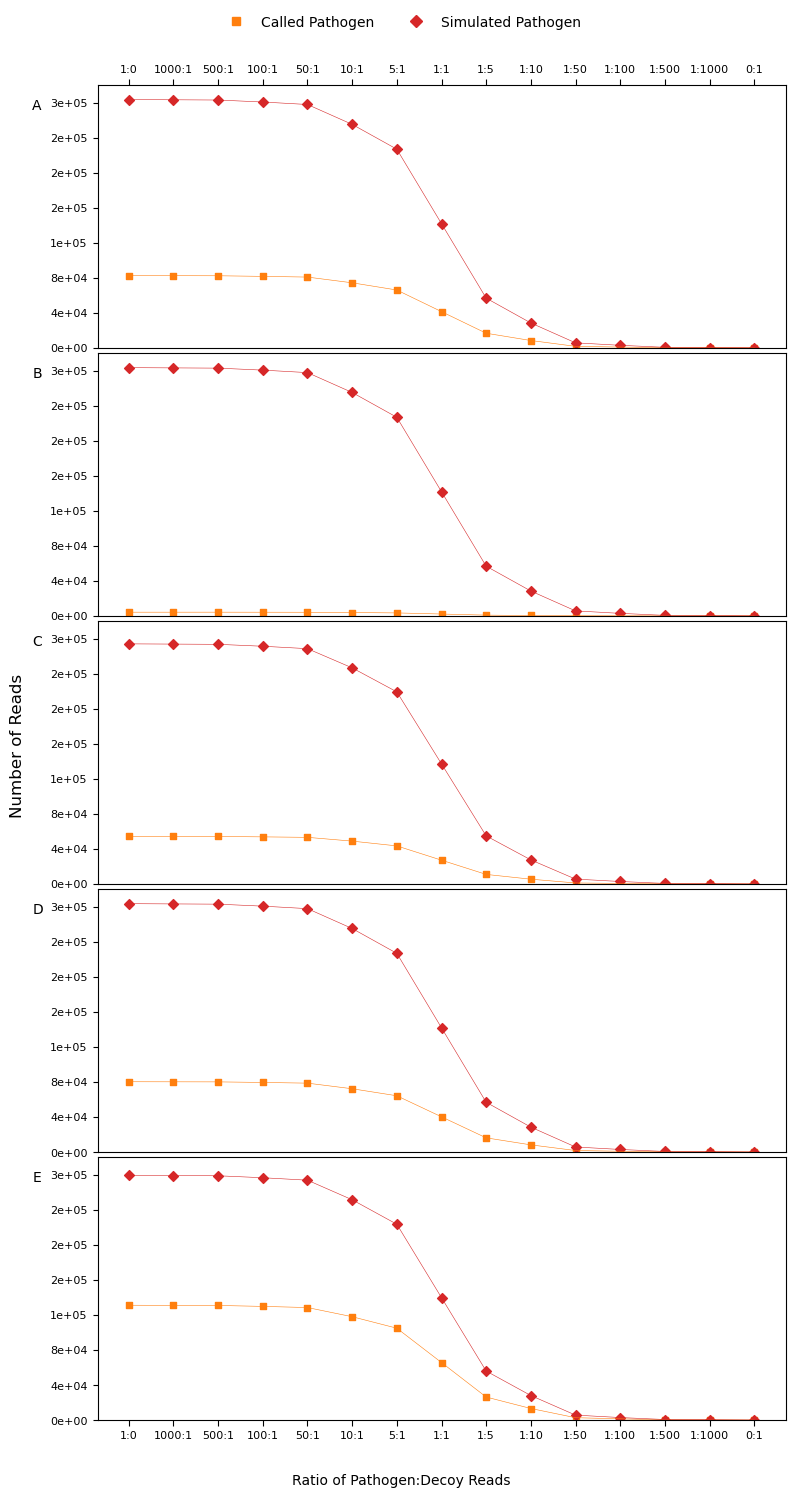

In [6]:
# ratio order
ratio_order = ["1:0", "1000:1", "500:1", "100:1", "50:1", "10:1", "5:1", "1:1", "1:5", "1:10", "1:50", "1:100", "1:500", "1:1000", "0:1"]

# categories
categories = [
    "Called Pathogen",
    "Simulated Pathogen"
]

# marker shapes
markers = {
    "Called Pathogen": "s",
    "Simulated Pathogen": "D"
}

# colours
colors = {
    "Simulated Pathogen": "tab:red",
    "Called Pathogen": "tab:orange",
}

# create 5-panel
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(8, 15),
    sharex=True 
)

# function to draw each dataset on an axis
def plot_f1(ax, data):
    data = data.copy()
    data["ratios"] = pd.Categorical(
        data["ratios"],
        categories=ratio_order,
        ordered=True
    )
    for category in categories:
        df = data[
            data["patho_decoy"] == category
        ].sort_values("ratios")
        if df.empty:
            continue
        x = df["ratios"].cat.codes
        #remove any ratios that are not in ratio_order
        valid = x>=0
        x = x[valid]
        y = df.loc[valid, "count"]
        # add points
        ax.scatter(
            x, y,
            marker=markers[category],
            color=colors[category],
            alpha=1,
            s=25
        )
        # add line
        ax.plot(
            x, y,
            color=colors[category],
            linewidth=0.4
        )

# plot the five datasets
plot_f1(axes[0], thuringiensis_f1_df)
plot_f1(axes[1], sporogenes_f1_df)
plot_f1(axes[2], coliSE11_f1_df)
plot_f1(axes[3], ftnovicida_f1_df)
plot_f1(axes[4], pseudot_f1_df)

# panel labels
labels = ["A", "B", "C", "D", "E"]

for ax, label in zip(axes, labels):

    ax.text(
        -0.095,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=10,
        color="black",
        va="top",
        ha="left"
    )

# x-axis positions
x_position = np.arange(len(ratio_order))
for ax in axes:
    ax.set_xticks(x_position)

# plot A x-axis settings
axes[0].xaxis.tick_top()
axes[0].set_xticks(x_position)
axes[0].set_xticklabels(ratio_order)

axes[0].tick_params(
    axis="x",
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    length=4,
    labelsize=8
)

# plots B-D x-axis labels and ticks removal
for ax in axes[1:4]:

    ax.set_xticklabels([])
    ax.tick_params(
        axis="x",
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False
    )

# plot E - x-axis
axes[4].xaxis.tick_bottom()
axes[4].set_xticks(x_position)
axes[4].set_xticklabels(ratio_order)

axes[4].tick_params(
    axis="x",
    bottom=True,
    labelbottom=True,
    top=False,
    labeltop=False,
    length=4,
    labelsize=8
)

# y-axis settings
for ax in axes:
    ax.set_ylim(0, 300000)
    ax.set_yticks(
        np.arange(0, 300001, 40000)
    )
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:.0e}")
    )
    ax.tick_params(
        axis="y",
        labelsize=8
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

# legends

legend_elements = [
    Line2D(
        [0], [0],
        marker=markers[category],
        color=colors[category],
        markerfacecolor=colors[category],
        markeredgecolor=colors[category],
        linestyle="None",
        markersize=6,
        label=category
    )
    for category in categories
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    fontsize=10
)

# whole figure axis labels
fig.text(
    0.02,
    0.5,
    "Number of Reads",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12
)

fig.text(
    0.5,
    0.01,
    "Ratio of Pathogen:Decoy Reads",
    ha="center",
    va="center",
    fontsize=10
)

# layout
plt.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.94,
    bottom=0.05,
    hspace=0.02
)

# save image
fig.savefig("IMAGES/figure_pathogenONLY_F1.png",
            dpi=600, bbox_inches="tight", facecolor="white"
)

plt.show()